In [130]:
import numpy as np
import pandas as pd
from numba import njit
import vectorbt as vbt
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns


In [131]:
# ========= 1. Data =========
tickers = ["BTC-USD", "ETH-USD", "DOGE-USD"]
data = vbt.YFData.download(tickers, start="2025-01-01", interval='4h')

close = data.get("Close").astype(np.float64).copy(deep=True)
high = data.get("High").astype(np.float64).copy(deep=True)
low = data.get("Low").astype(np.float64).copy(deep=True)



In [132]:
# ========= 2. Signal Data Comparison =========
print(f"\npandas_ta")
sar_pandas_ta = vbt.pandas_ta('psar').run(high, low, close=close, acceleration=0.02, maximum=0.2)
print(sar_pandas_ta.psarl.tail())
sar_buy = sar_pandas_ta.psarl_below(close)

adx_pandas_ta = vbt.pandas_ta('adx').run(high, low, close, length=14)
dmp_cross = adx_pandas_ta.dmp_above(adx_pandas_ta.dmn)
adx_threshold_cross = adx_pandas_ta.adx_above(25)
adx_buy = dmp_cross & adx_threshold_cross
# adx_buy.columns = buy2.columns.droplevel(0)
print(f"\ndmp > dmn")
print(adx_buy.tail())

ce = vbt.pandas_ta('chandelier_exit').run(high, low, close, multiplier=3)
print(f"\nChandelier Exit")
ce_exit = ce.chdlrextl

print(ce_exit.tail())
ce_signal = ce_exit.values > low
# ce_signal = ce.chdlrextd > 0

print(ce_signal.tail())

entries = sar_buy & adx_buy

exits = ce_signal

print(f"\nentries")
print(entries.tail())






pandas_ta
symbol                          BTC-USD      ETH-USD  DOGE-USD
Datetime                                                      
2025-11-08 04:00:00+00:00  99497.137453  3208.309341  0.165391
2025-11-08 08:00:00+00:00  99587.927517  3218.968295  0.167502
2025-11-08 12:00:00+00:00  99676.901779  3229.200892  0.169359
2025-11-08 16:00:00+00:00  99764.096556  3239.024184  0.170994
2025-11-08 20:00:00+00:00  99849.547437  3248.454545  0.172432

dmp > dmn
adx_length                     14                 
symbol                    BTC-USD ETH-USD DOGE-USD
Datetime                                          
2025-11-08 04:00:00+00:00   False   False     True
2025-11-08 08:00:00+00:00   False   False     True
2025-11-08 12:00:00+00:00   False   False     True
2025-11-08 16:00:00+00:00   False   False     True
2025-11-08 20:00:00+00:00   False   False     True

Chandelier Exit
chandelier_exit_multiplier              3                       
symbol                            BTC-USD      

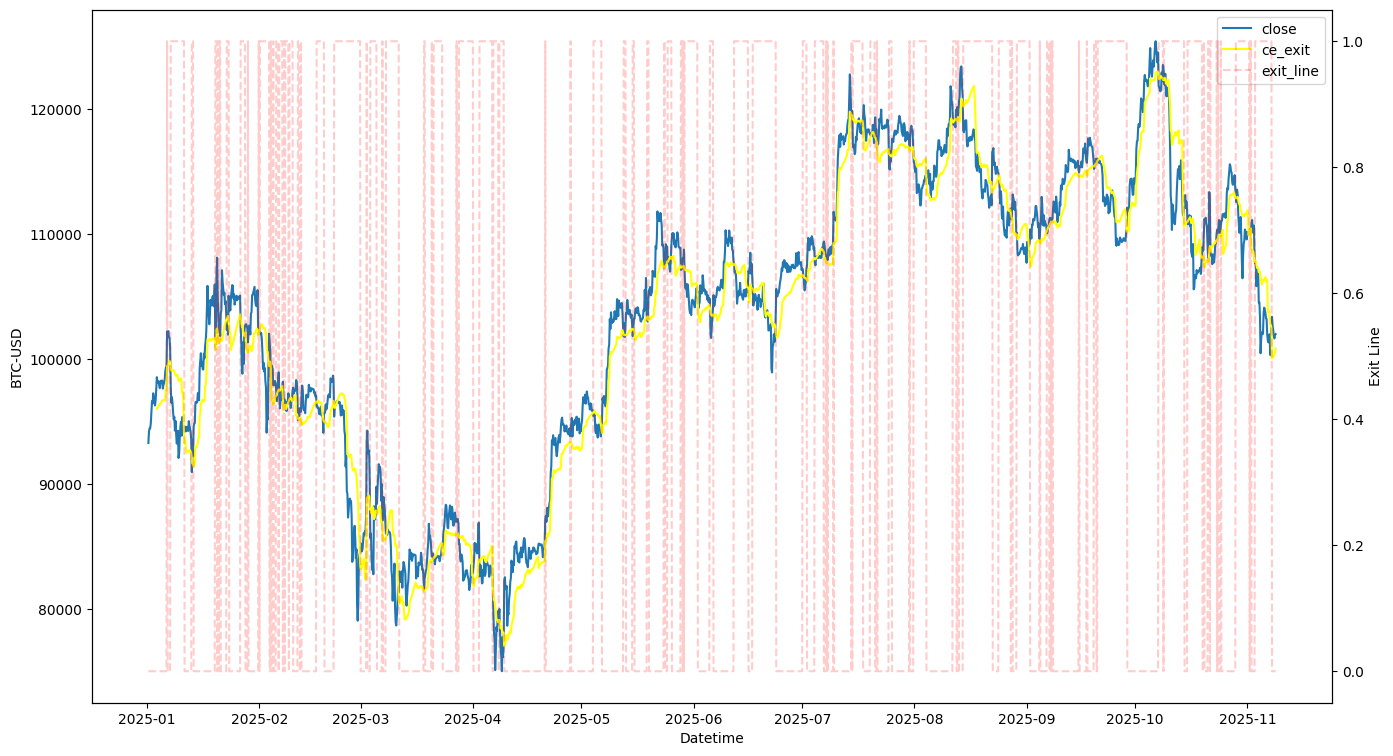

In [133]:
ce_data = ce_exit.xs('BTC-USD', axis=1, level='symbol').squeeze()  # Convert to Series

exit_line = (ce_data > low['BTC-USD']).squeeze()

fig, ax = plt.subplots( figsize=(16, 9))
sns.lineplot(data=close['BTC-USD'], ax=ax, label='close')
sns.lineplot(data=ce_data, color='yellow', ax=ax, label='ce_exit')
# Create secondary y-axis and plot on it using matplotlib
ax2 = ax.twinx()
ax2.plot(exit_line.index, exit_line.values, color='red', label='exit_line',linestyle='--',alpha=0.2)
ax2.set_ylabel('Exit Line')

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()

In [134]:
pf = vbt.Portfolio.from_signals(close,
                                entries=entries,
                                exits=exits,
                                size=1,
                                size_type='percent',
                                direction='longonly',
                                sl_stop=0.1,
                                sl_trail=True,
                                freq='4h',
                                fees=0.004,
                                init_cash=1000,
                                )

In [135]:
pf_btc = pf[pf.wrapper.columns[0]]

stats_df = pd.DataFrame()
for col in pf.wrapper.columns:
    pf_col = pf[col]
    stats_df = pd.concat([stats_df, pf_col.stats()], axis=1)

print(stats_df.to_string())



                                        (14, BTC-USD)              (14, ETH-USD)             (14, DOGE-USD)
Start                       2025-01-01 08:00:00+00:00  2025-01-01 08:00:00+00:00  2025-01-01 08:00:00+00:00
End                         2025-11-08 20:00:00+00:00  2025-11-08 20:00:00+00:00  2025-11-08 20:00:00+00:00
Period                              311 days 16:00:00          311 days 16:00:00          311 days 16:00:00
Start Value                                    1000.0                     1000.0                     1000.0
End Value                                  827.321883                1169.884934                  767.46021
Total Return [%]                           -17.267812                  16.988493                 -23.253979
Benchmark Return [%]                         9.340661                   1.582415                  -44.51802
Max Gross Exposure [%]                          100.0                      100.0                      100.0
Total Fees Paid             

In [136]:
pf[pf.wrapper.columns[1]].plot().show()